DATASET INFORMATION
Shape: (284807, 31)

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Fraud Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


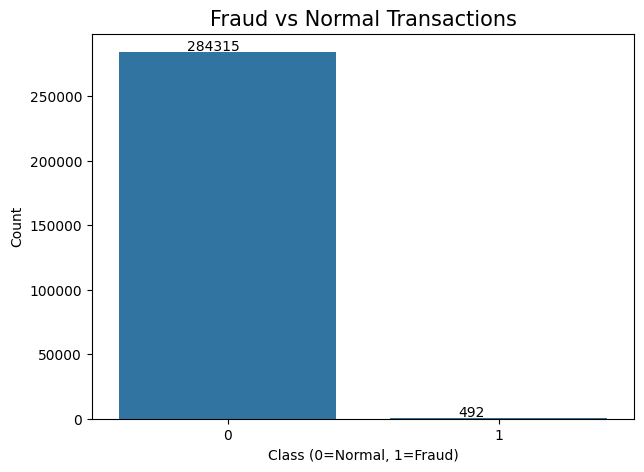

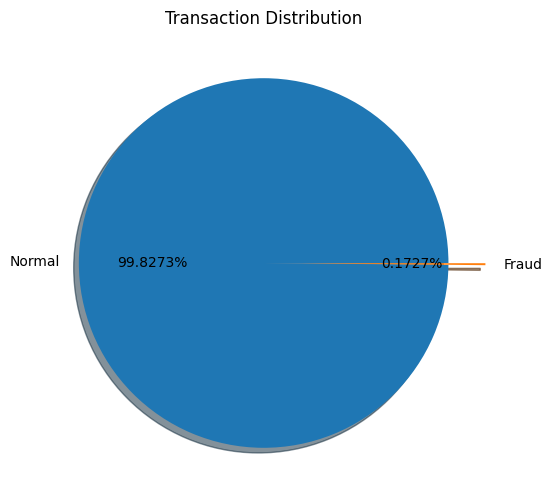

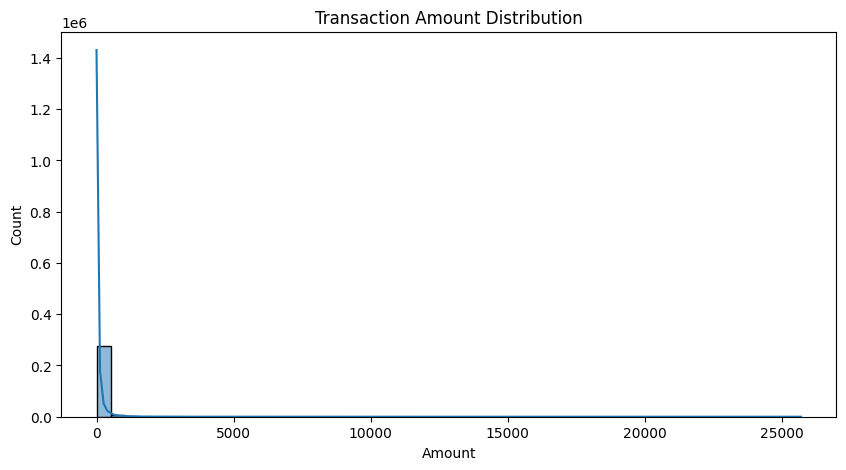

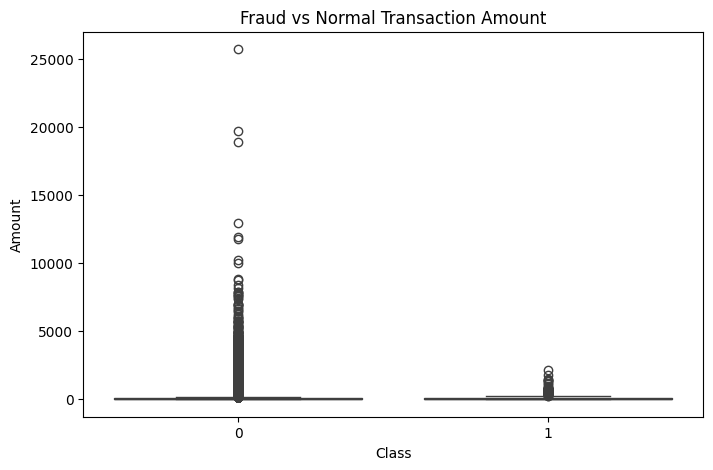

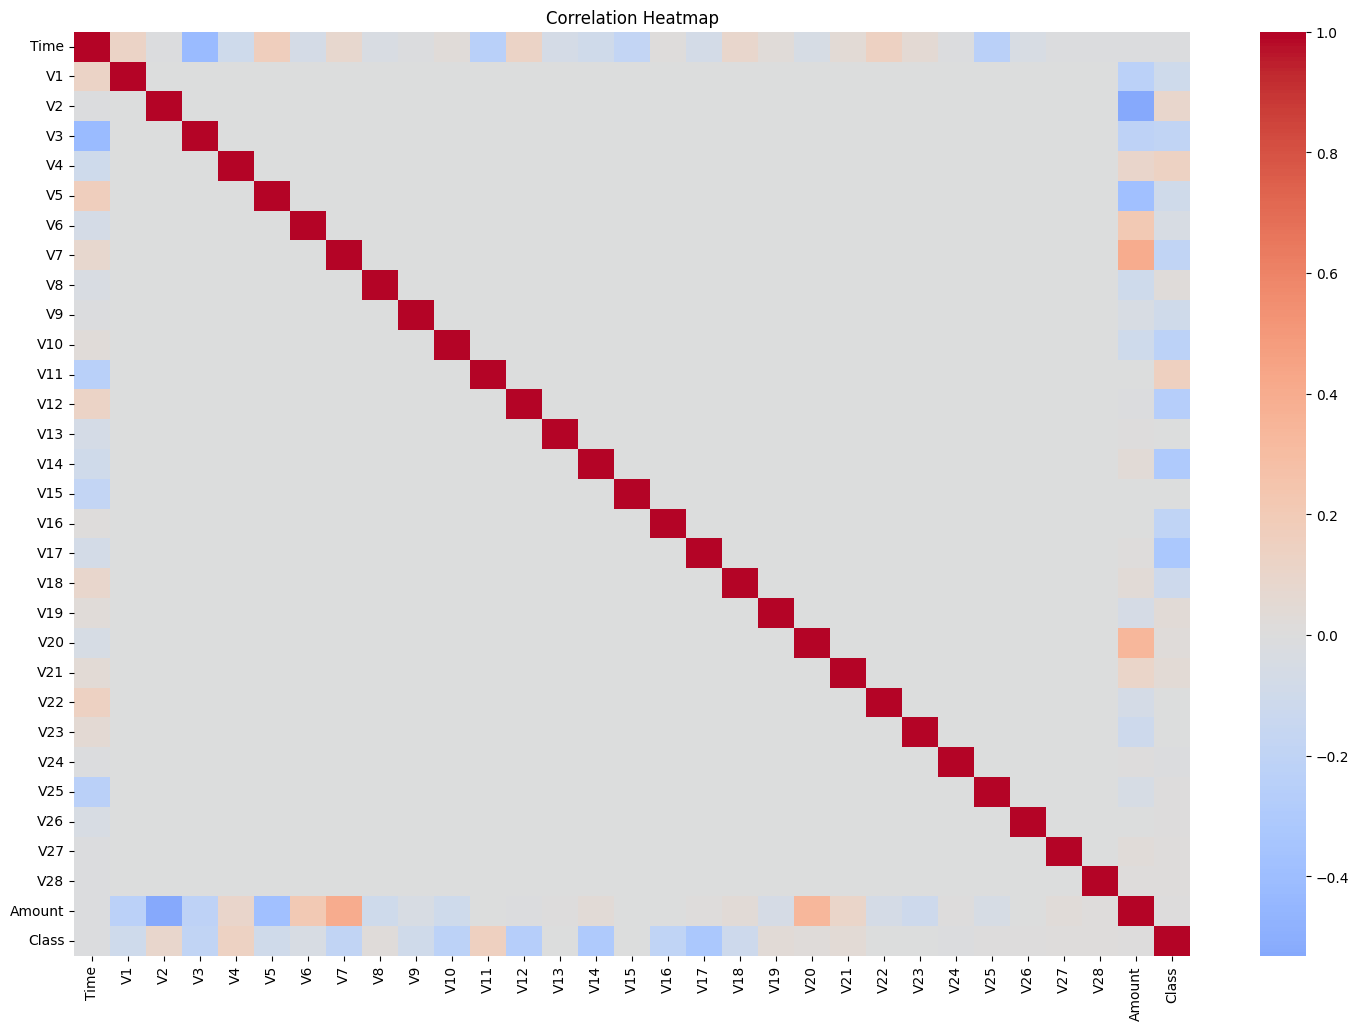


LOGISTIC REGRESSION
Accuracy : 0.9991573329588147
Precision: 0.8289473684210527
Recall   : 0.6428571428571429
F1 Score : 0.7241379310344828

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


DECISION TREE
Accuracy : 0.9994733330992591
Precision: 0.8953488372093024
Recall   : 0.7857142857142857
F1 Score : 0.8369565217391305

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962


RANDOM FOREST
Accuracy 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)

# ======================================
# LOAD DATA
# ======================================

df = pd.read_csv("creditcard.csv")

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nFraud Distribution:")
print(df['Class'].value_counts())

# ======================================
# ATTRACTIVE VISUALIZATION 1
# CLASS DISTRIBUTION
# ======================================

plt.figure(figsize=(7,5))
ax = sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions", fontsize=15)
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+0.25, p.get_height()+1000)
    )

plt.show()

# ======================================
# ATTRACTIVE VISUALIZATION 2
# FRAUD PERCENTAGE
# ======================================

fraud = len(df[df['Class']==1])
normal = len(df[df['Class']==0])

plt.figure(figsize=(6,6))

plt.pie(
    [normal, fraud],
    labels=['Normal','Fraud'],
    autopct='%1.4f%%',
    explode=(0,0.2),
    shadow=True
)

plt.title("Transaction Distribution")
plt.show()

# ======================================
# ATTRACTIVE VISUALIZATION 3
# AMOUNT DISTRIBUTION
# ======================================

plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

# ======================================
# ATTRACTIVE VISUALIZATION 4
# FRAUD VS NORMAL AMOUNT
# ======================================

plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Normal Transaction Amount")
plt.show()

# ======================================
# CORRELATION HEATMAP
# ======================================

plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# ======================================
# FEATURE ENGINEERING
# ======================================

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(
    df[['Amount']]
)

df['Time'] = scaler.fit_transform(
    df[['Time']]
)

X = df.drop('Class', axis=1)
y = df['Class']

# ======================================
# TRAIN TEST SPLIT
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================
# LOGISTIC REGRESSION
# ======================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# ======================================
# DECISION TREE
# ======================================

dt = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# ======================================
# RANDOM FOREST
# ======================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# ======================================
# ISOLATION FOREST
# ANOMALY DETECTION
# ======================================

iso = IsolationForest(
    contamination=0.0017,
    random_state=42
)

iso.fit(X_train)

iso_pred = iso.predict(X_test)

iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

# ======================================
# EVALUATION FUNCTION
# ======================================

def evaluate(name, y_true, pred):

    acc = accuracy_score(y_true, pred)
    pre = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred)
    f1 = f1_score(y_true, pred)

    print("\n"+"="*60)
    print(name)
    print("="*60)

    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    print("\nClassification Report")
    print(classification_report(
        y_true,
        pred
    ))

    return [acc, pre, rec, f1]

# ======================================
# MODEL EVALUATION
# ======================================

lr_metrics = evaluate(
    "LOGISTIC REGRESSION",
    y_test,
    lr_pred
)

dt_metrics = evaluate(
    "DECISION TREE",
    y_test,
    dt_pred
)

rf_metrics = evaluate(
    "RANDOM FOREST",
    y_test,
    rf_pred
)

iso_metrics = evaluate(
    "ISOLATION FOREST",
    y_test,
    iso_pred
)

# ======================================
# MODEL COMPARISON
# ======================================

results = pd.DataFrame({
    'Model':
    [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Isolation Forest'
    ],
    'F1 Score':
    [
        lr_metrics[3],
        dt_metrics[3],
        rf_metrics[3],
        iso_metrics[3]
    ]
})

print(results)

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x='Model',
    y='F1 Score'
)

plt.title("Model Comparison (F1 Score)")
plt.xticks(rotation=15)

plt.show()

# ======================================
# RANDOM FOREST CONFUSION MATRIX
# ======================================

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ======================================
# ROC CURVE
# ======================================

rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    rf_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

# ======================================
# FEATURE IMPORTANCE
# ======================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features")
print(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

# ======================================
# REAL-TIME FRAUD PREDICTION
# ======================================

def predict_transaction(sample):

    pred = rf.predict(sample)

    if pred[0] == 1:
        print("⚠ FRAUD TRANSACTION DETECTED")
    else:
        print("✓ LEGITIMATE TRANSACTION")

sample = X_test.iloc[0:1]

predict_transaction(sample)

import joblib

joblib.dump(rf, "fraud_model.pkl")